# Electric Vehicle Adoption Analysis
Using ev_sales_by_makers_and_cat_15-24.csv

In [1]:
import pandas
import matplotlib.pyplot as plt
df=pandas.read_csv("ev_sales_by_makers_and_cat_15-24.csv")
df.head()
df.info()
df.describe()
df.dtypes


<class 'pandas.DataFrame'>
RangeIndex: 1386 entries, 0 to 1385
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Cat     1386 non-null   str  
 1   Maker   1386 non-null   str  
 2   2015    1386 non-null   int64
 3   2016    1386 non-null   int64
 4   2017    1386 non-null   int64
 5   2018    1386 non-null   int64
 6   2019    1386 non-null   int64
 7   2020    1386 non-null   int64
 8   2021    1386 non-null   int64
 9   2022    1386 non-null   int64
 10  2023    1386 non-null   int64
 11  2024    1386 non-null   int64
dtypes: int64(10), str(2)
memory usage: 130.1 KB


Cat        str
Maker      str
2015     int64
2016     int64
2017     int64
2018     int64
2019     int64
2020     int64
2021     int64
2022     int64
2023     int64
2024     int64
dtype: object

In [2]:
df.isnull().sum()
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.duplicated().sum()
df.isnull().sum().sort_values(ascending=False)


Cat      0
Maker    0
2015     0
2016     0
2017     0
2018     0
2019     0
2020     0
2021     0
2022     0
2023     0
2024     0
dtype: int64

In [3]:
# Fill missing values
df['Maker'] = df['Maker'].fillna(df['Maker'].mode()[0])
df['Cat'] = df['Cat'].fillna(df['Cat'].mode()[0])
df['2024'] = df['2024'].fillna(df['2024'].median())
df['2015'] = pandas.to_numeric(df['2015'], errors='coerce')
df['2016'] = pandas.to_numeric(df['2016'], errors='coerce')
df['2017'] = pandas.to_numeric(df['2017'], errors='coerce')
df['2018'] = pandas.to_numeric(df['2018'], errors='coerce')
df['2019'] = pandas.to_numeric(df['2019'], errors='coerce')
df['2020'] = pandas.to_numeric(df['2020'], errors='coerce')
df['2021'] = pandas.to_numeric(df['2021'], errors='coerce')
df['2022'] = pandas.to_numeric(df['2022'], errors='coerce')
df['2023'] = pandas.to_numeric(df['2023'], errors='coerce')
df['2024'] = pandas.to_numeric(df['2024'], errors='coerce')


In [4]:
df['total_sales'] = (
    df['2015'] +
    df['2016'] +
    df['2017'] +
    df['2018'] +
    df['2019'] +
    df['2020'] +
    df['2021'] +
    df['2022'] +
    df['2023'] +
    df['2024']
)


In [5]:
df['average_sales'] = df['total_sales'] / 10
df[['total_sales','average_sales']].head()

,total_sales,average_sales
0,43,4.3
1,1098,109.8
2,1,0.1
3,2,0.2
4,1069,106.9


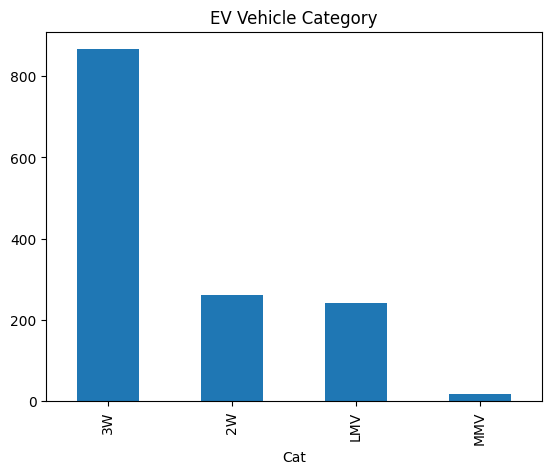

In [6]:
df['Cat'].value_counts().plot(kind='bar')

plt.title("EV Vehicle Category")
plt.show()

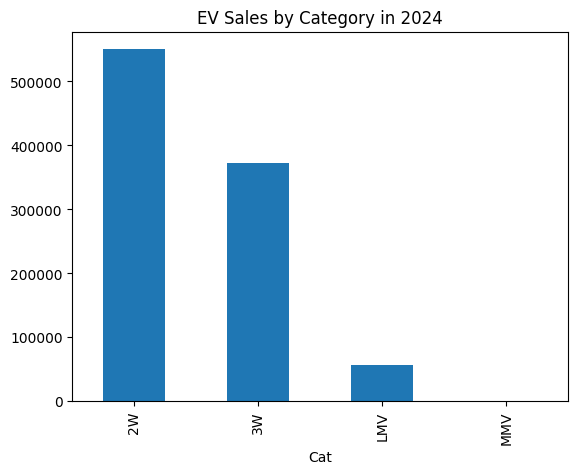

In [7]:
df.groupby('Cat')['2024'].sum().plot(kind='bar')

plt.title("EV Sales by Category in 2024")
plt.show()

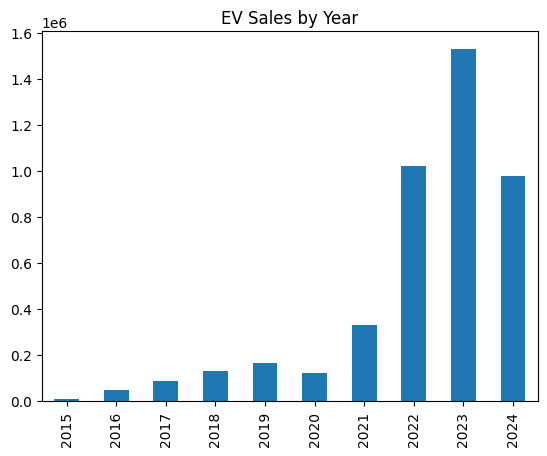

In [8]:
df[['2015','2016','2017','2018','2019','2020','2021','2022','2023','2024']].sum().plot(kind='bar')

plt.title("EV Sales by Year")
plt.show()

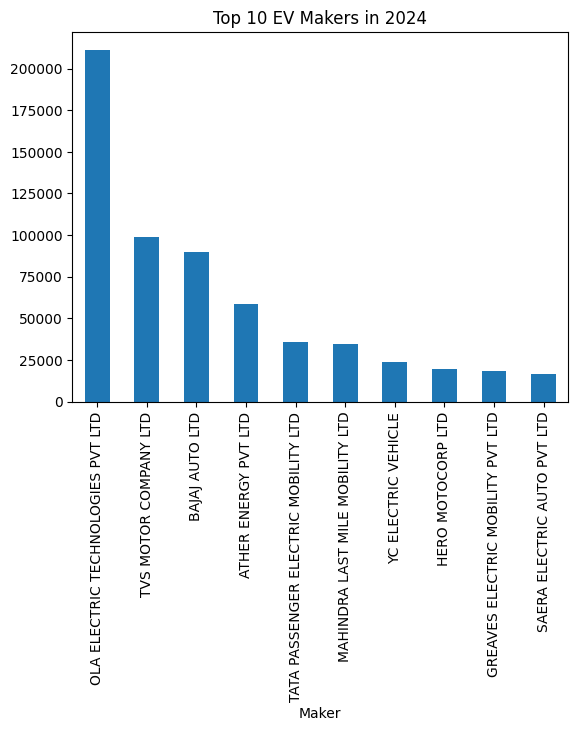

In [9]:
df.groupby('Maker')['2024'].sum().sort_values(ascending=False).head(10).plot(kind='bar')

plt.title("Top 10 EV Makers in 2024")
plt.show()

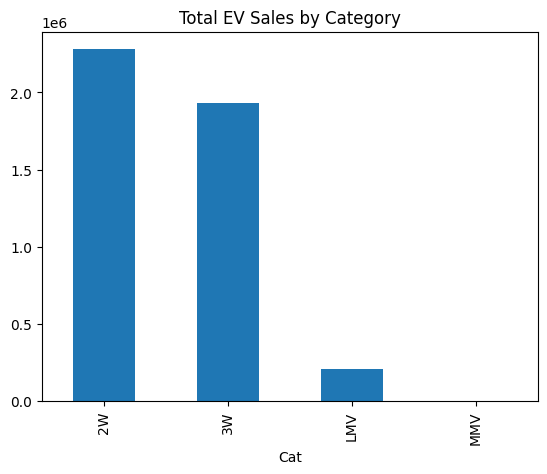

In [10]:
df.groupby('Cat')['total_sales'].sum().plot(kind='bar')

plt.title("Total EV Sales by Category")
plt.show()

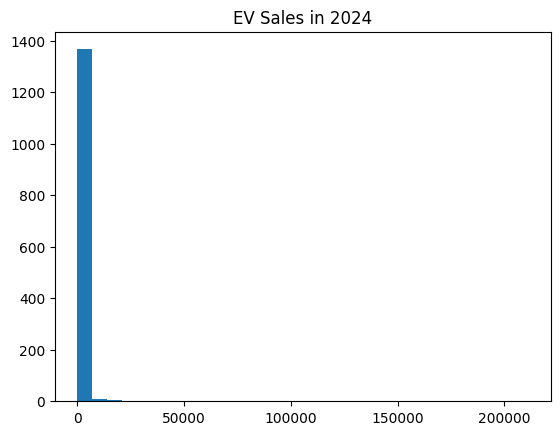

In [11]:
plt.hist(df['2024'], bins=30)
plt.title("EV Sales in 2024")
plt.show()

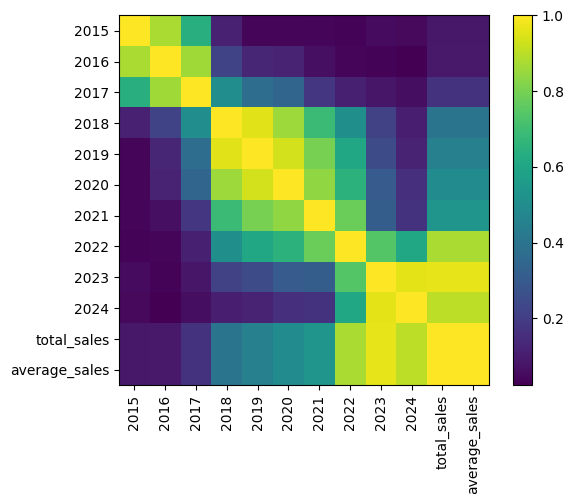

In [12]:
corr = df.select_dtypes(include='number').corr()

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.show()